# $H_{\text{local}}(x,t)$ — Score de stress hydrique territorial

## Objectif

Score décisionnel pour évaluer la **contrainte hydrique territoriale** d'un site candidat
à l'implantation d'un data center. Ce score ne modélise pas l'hydrologie ;
il agrège des indicateurs publics en un signal interprétable et stable.

---

## 1. Définition mathématique

$$H_{\text{local}}(x,t) \;=\; \beta(t) \;\cdot\; S_{\text{struct}}(x) \;+\; (1-\beta(t)) \;\cdot\; S_{\text{conj}}(x,t) \qquad \in [0,\,1]$$

avec $\beta(t) = \beta_0 \cdot (1 - S_{\text{conj}})$ — en crise, le conjoncturel pèse davantage.

où $0$ = favorable, $1$ = contrainte forte.

### 1.1 Composante structurelle (invariante temporelle)

$$S_{\text{struct}}(x) \;=\; \alpha_B \;\widetilde{BWS}(x) \;+\; \alpha_A \; A(x) \;+\; \alpha_G \;\widetilde{GWS}(x)$$

| Variable | Notation | Transformation | Source | Référence |
|---|---|---|---|---|
| Baseline Water Stress | $\widetilde{BWS} = \text{clip}\!\left(\frac{BWS_{\text{raw}}}{0.6},\;0,\;1\right)$ | Linéaire, rescalé sur max France | WRI Aqueduct 4.0 | Kuzma et al. (2023) |
| Aridity | $A = \frac{1}{1 + (AI / 0.65)^3}$, $\;AI = \overline{P} / \overline{PET}$ | Sigmoïde calibrée sur seuils UNEP | ERA5 baseline 1981–2010 | UNEP (1992), Middleton & Thomas (1997) |
| Groundwater Stress | $\widetilde{GWS} = \text{clip}\!\left(\frac{GWS_{\text{raw}}}{0.15},\;0,\;1\right)$ | Linéaire, rescalé sur max France | WRI Aqueduct 4.0 | Kuzma et al. (2023) |

### 1.2 Composante conjoncturelle (dynamique)

$$S_{\text{conj}}(x,t) \;=\; \max\!\Big(\,f\big(\text{SPEI-12}(x,t)\big),\;\; f\big(\text{SPEI-3}(x,t)\big)\,\Big)$$

$$f(\text{SPEI}) \;=\; \text{clip}\!\left(\frac{-\text{SPEI}^*}{3},\;0,\;1\right), \qquad \text{SPEI}^* = \text{clip}(\text{SPEI},\;-3,\;+3)$$

| Choix | Justification |
|---|---|
| $\max(\cdot)$ | Conservateur : retient le pire signal entre déficit cumulé (12 mois) et choc court (3 mois). Choix **produit**, pas scientifiquement neutre. |
| Cap $[-3, +3]$ | Au-delà, le SPEI est un artefact numérique du fit log-logistique (saturation de $\Phi^{-1}$). Stabilise les extrêmes. |
| Fit par mois calendaire | 12 distributions fisk ajustées séparément. Réf : Beguería et al. (2014). |

### 1.3 Paramètres

| Symbole | Valeur | Rôle |
|---|---|---|
| $\beta_0$ | $0.70$ | Part structurelle de base (modulée par $S_{\text{conj}}$) |
| $\alpha_B$ | $0.50$ | Poids intra-bloc BWS |
| $\alpha_A$ | $0.36$ | Poids intra-bloc aridité |
| $\alpha_G$ | $0.14$ | Poids intra-bloc GWS |

**Tous les poids sont fixés à dire d'expert, non calibrés.**

### 1.4 Correction pixel côtier ERA5

ERA5 à 0.25° mélange terre et mer pour les pixels côtiers, ce qui dilue la PET.
Si $PET_{\text{centre}} < 60\%$ de $\max(PET_{3\times3})$, on reroute vers le gridpoint
continental voisin (PET max). Affecte Marseille et Montpellier.
Réf : Hersbach et al. (2020), QJRMS.

### 1.5 Références

| Ref | Citation |
|---|---|
| Kuzma et al. (2023) | *Aqueduct 4.0: Updated Decision-Relevant Global Water Risk Indicators.* WRI Technical Note. |
| Vicente-Serrano et al. (2010) | *A Multiscalar Drought Index Sensitive to Global Warming: The SPEI.* J. Climate, 23(7), 1696–1718. |
| Beguería et al. (2014) | *Standardized precipitation evapotranspiration index (SPEI) revisited.* Int. J. Climatol., 34, 3001–3023. |
| UNEP (1992) | *World Atlas of Desertification.* United Nations Environment Programme. |
| Middleton & Thomas (1997) | *World Atlas of Desertification.* 2nd ed., Arnold. |
| Hersbach et al. (2020) | *The ERA5 global reanalysis.* QJRMS, 146(730), 1999–2049. |
| McKee et al. (1993) | *The relationship of drought frequency and duration to time scales.* 8th Conf. Applied Climatology, AMS. |
| Vidal et al. (2010) | *A 50-year high-resolution atmospheric reanalysis over France.* Int. J. Climatol., 30(11), 1627–1644. |
| Bonnet et al. (2024) | *The 2022 drought in France.* INRAE report. |

---
## 2. Setup

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import rasterio
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# -- Chemins --
BASE = Path("../water_model/data")
RAW  = BASE / "raw"
AQUEDUCT_BWS = RAW / "aqueduct" / "bws_raw.tif"
AQUEDUCT_GWS = RAW / "aqueduct" / "gws_raw.tif"
ERA5_FULL    = RAW / "era5" / "era5_monthly_1981_2022.nc"

# -- Sites de validation --
SITES = {
    "Paris-Saclay":  (48.73, 2.17),
    "Lyon":          (45.76, 4.83),
    "Marseille":     (43.30, 5.37),
    "Strasbourg":    (48.57, 7.75),
    "Brest":         (48.39, -4.49),
    "Rennes":        (48.11, -1.68),
    "Bordeaux":      (44.84, -0.58),
    "Montpellier":   (43.61, 3.88),
}

# -- Parametres du modele --
BWS_MAX_FR = 0.60     # max France ~ 0.5, marge 20%
GWS_MAX_FR = 0.15     # max France ~ 0.1, marge 50%
SIGMOID_A   = 3.0      # [-3, +3] credible
ALPHA = {"bws": 0.50, "aridity": 0.36, "gws": 0.14}
BETA  = 0.70           # 70% structurel

VALIDATION_DATES = [
    (2015, 7, "2015 -- normale"),
    (2018, 7, "2018 -- canicule"),
    (2022, 7, "2022 -- secheresse"),
]

print("Setup OK")
for f in [AQUEDUCT_BWS, AQUEDUCT_GWS, ERA5_FULL]:
    print(f"  {f.name:30s} : {'OK' if f.exists() else 'MANQUANT'}")

Setup OK
  bws_raw.tif                    : OK
  gws_raw.tif                    : OK
  era5_monthly_1981_2022.nc      : OK


---
## 3. Fonctions du modele

In [2]:
# ==================================================================
# 3.1 Extraction raster (Aqueduct)
# ==================================================================

def extract_raster_point(raster_path, lat, lon):
    """Extrait la valeur au point (lat, lon) dans un GeoTIFF."""
    with rasterio.open(raster_path) as src:
        vals = list(src.sample([(lon, lat)]))
        val = float(vals[0][0])
        if src.nodata is not None and val == src.nodata:
            return np.nan
        return val


# ==================================================================
# 3.2 SPEI -- fit log-logistique par mois calendaire
# ==================================================================
# Ref: Vicente-Serrano et al. (2010), Begueria et al. (2014)

def compute_spei(precip_mm, pet_mm, dates, window=12,
                 baseline_start=1981, baseline_end=2010):
    """
    SPEI-N avec fit fisk PAR MOIS calendaire.
    12 distributions log-logistiques ajustees separement.
    """
    D = precip_mm - pet_mm
    n = len(D)
    D_acc = np.full(n, np.nan)
    for i in range(window - 1, n):
        D_acc[i] = np.sum(D[i - window + 1 : i + 1])

    years, months = dates.year, dates.month
    mask_base = (years >= baseline_start) & (years <= baseline_end)

    monthly_params = {}
    for m in range(1, 13):
        mask_m = (months == m) & mask_base & ~np.isnan(D_acc)
        base_m = D_acc[mask_m]
        if len(base_m) < 10:
            monthly_params[m] = None
            continue
        shift_m = -np.min(base_m) + 1.0
        try:
            c, _, scale = stats.fisk.fit(base_m + shift_m, floc=0)
            _, ks_pval = stats.kstest(base_m + shift_m, 'fisk', args=(c, 0, scale))
            monthly_params[m] = (c, scale, shift_m, ks_pval, len(base_m))
        except Exception:
            monthly_params[m] = None

    spei = np.full(n, np.nan)
    for i in range(n):
        if np.isnan(D_acc[i]):
            continue
        params = monthly_params.get(months[i])
        if params is None:
            continue
        c, scale, shift_m, _, _ = params
        prob = stats.fisk.cdf(D_acc[i] + shift_m, c, loc=0, scale=scale)
        prob = np.clip(prob, 1e-6, 1 - 1e-6)
        spei[i] = stats.norm.ppf(prob)

    ks_pvals = [p[3] for p in monthly_params.values() if p is not None]
    return {
        'spei': spei, 'D_monthly': D, 'D_acc': D_acc,
        'ks_pvalue': np.mean(ks_pvals) if ks_pvals else 0.0,
        'monthly_params': monthly_params,
    }


# ==================================================================
# 3.3 Aridity -- sigmoide UNEP
# ==================================================================
# Ref: UNEP (1992), Middleton & Thomas (1997)
# AI_mid = 0.65 (seuil sub-humide sec), k = 3

def aridity_stress(ai, ai_mid=0.65, k=3.0):
    """Stress = 1 / (1 + (AI / AI_mid)^k)."""
    if ai <= 0:
        return 1.0
    return float(1.0 / (1.0 + (ai / ai_mid) ** k))

def compute_aridity(precip_mm, pet_mm, dates,
                    baseline_start=1981, baseline_end=2010):
    """AI = P_annuel / PET_annuel sur baseline, puis stress sigmoide."""
    years = dates.year
    mask = (years >= baseline_start) & (years <= baseline_end)
    n_years = baseline_end - baseline_start + 1
    p_ann = np.sum(precip_mm[mask]) / n_years
    pet_ann = np.sum(pet_mm[mask]) / n_years
    if pet_ann <= 0:
        return 0.0, 999.0
    ai = p_ann / pet_ann
    return aridity_stress(ai), ai


# ==================================================================
# 3.4 Correction pixel cotier ERA5
# ==================================================================
# Ref: Hersbach et al. (2020)

def find_land_gridpoint(lat, lon, ds, threshold=0.60):
    """Detecte pixel cotier, reroute vers voisin continental."""
    td = 'valid_time' if 'valid_time' in ds.dims else 'time'
    lats, lons = ds.latitude.values, ds.longitude.values
    i_lat = int(np.argmin(np.abs(lats - lat)))
    i_lon = int(np.argmin(np.abs(lons - lon)))
    times = pd.DatetimeIndex(ds[td].values)
    month_idx = next(k for k in range(len(times)-1, -1, -1) if times[k].month == 7)
    lat_sl = slice(max(0, i_lat-1), min(len(lats), i_lat+2))
    lon_sl = slice(max(0, i_lon-1), min(len(lons), i_lon+2))
    pev_3x3 = ds['pev'].isel({td: month_idx, 'latitude': lat_sl, 'longitude': lon_sl})
    pet_3x3 = np.maximum(-pev_3x3.values.astype(float), 0.0)
    pet_center = pet_3x3[min(1, i_lat), min(1, i_lon)]
    pet_max = np.max(pet_3x3)
    ratio = pet_center / pet_max if pet_max > 0 else 1.0
    if ratio >= threshold:
        return lats[i_lat], lons[i_lon], False
    local_lats, local_lons = lats[lat_sl], lons[lon_sl]
    max_pos = np.unravel_index(np.argmax(pet_3x3), pet_3x3.shape)
    return float(local_lats[max_pos[0]]), float(local_lons[max_pos[1]]), True


# ==================================================================
# 3.5 Score final
# ==================================================================

def spei_to_stress(spei_val, c=2.0):
    """
    Mapping asymptotique non saturant :
      f(SPEI) = max(0, -SPEI / (c + |SPEI|))
    - c = 2.0 : controle la vitesse de convergence vers 1
    - SPEI = 0  -> 0.00  (neutre)
    - SPEI = -1 -> 0.33
    - SPEI = -2 -> 0.50
    - SPEI = -3 -> 0.60  (vs 1.0 avec clip — plus de saturation)
    - SPEI = -5 -> 0.71
    Asymptote a 1, jamais atteinte : preserve la variance en crise.
    """
    if np.isnan(spei_val):
        return np.nan
    if spei_val >= 0:
        return 0.0
    return float(-spei_val / (c + abs(spei_val)))

print("Fonctions chargees")

Fonctions chargees


---
## 4. Pipeline

In [3]:
# ==================================================================
# 4. Calcul H_local multi-sites x multi-annees
# ==================================================================

ds = xr.open_dataset(ERA5_FULL)
td = 'valid_time' if 'valid_time' in ds.dims else 'time'

# 4.1 Detection pixels cotiers
coastal_map = {}
print("=== Detection pixels cotiers ===")
for name, (lat, lon) in SITES.items():
    blat, blon, coastal = find_land_gridpoint(lat, lon, ds)
    coastal_map[name] = (blat, blon, coastal)
    if coastal:
        print(f"  {name:14s} : COASTAL -> ({blat:.2f}, {blon:.2f})")
print()

# 4.2 Calcul
results = []
for name, (lat, lon) in SITES.items():
    bws_raw = extract_raster_point(AQUEDUCT_BWS, lat, lon)
    gws_raw = extract_raster_point(AQUEDUCT_GWS, lat, lon)
    pet_lat, pet_lon, is_coastal = coastal_map[name]

    tp = ds['tp'].sel(latitude=lat, longitude=lon, method='nearest')
    t = pd.DatetimeIndex(tp[td].values)
    dy = t.days_in_month.values.astype(float)
    p = np.maximum(tp.values.astype(float) * dy * 1000, 0)
    pv = ds['pev'].sel(latitude=pet_lat, longitude=pet_lon, method='nearest')
    pet = np.maximum(-pv.values.astype(float) * dy * 1000, 0)

    b = float(np.clip(bws_raw / BWS_MAX_FR, 0, 1)) if not np.isnan(bws_raw) else np.nan
    g = float(np.clip(gws_raw / GWS_MAX_FR, 0, 1)) if not np.isnan(gws_raw) else np.nan
    a_stress, ai = compute_aridity(p, pet, t)
    sr12 = compute_spei(p, pet, t, window=12)
    sr3  = compute_spei(p, pet, t, window=3)

    for year, month, label in VALIDATION_DATES:
        idx = next((i for i, tt in enumerate(t)
                    if tt.year == year and tt.month == month), None)
        if idx is None:
            continue

        # S_struct
        comps = {'bws': b, 'aridity': a_stress, 'gws': g}
        num = sum(ALPHA[k] * v for k, v in comps.items()
                  if v is not None and not np.isnan(v))
        den = sum(ALPHA[k] for k, v in comps.items()
                  if v is not None and not np.isnan(v))
        s_struct = num / den if den > 0 else np.nan

        # S_conj = softmax(f(SPEI-12), f(SPEI-3), tau=5)
        d12 = spei_to_stress(sr12['spei'][idx])
        d3  = spei_to_stress(sr3['spei'][idx])
        if np.isnan(d12) and np.isnan(d3):
            s_conj = np.nan
        elif np.isnan(d3):
            s_conj = d12
        elif np.isnan(d12):
            s_conj = d3
        else:
            TAU = 5.0
            e12 = np.exp(TAU * d12)
            e3  = np.exp(TAU * d3)
            s_conj = (d12 * e12 + d3 * e3) / (e12 + e3)

        # H = beta(t) * S_struct + (1-beta(t)) * S_conj
        # beta dynamique : en crise, le conjoncturel pese plus
        # beta(t) = beta_0 * (1 - S_conj)  =>  crise forte -> struct diminue
        if np.isnan(s_struct) and np.isnan(s_conj):
            H = np.nan
        elif np.isnan(s_struct):
            H = s_conj
        elif np.isnan(s_conj):
            H = s_struct
        else:
            beta_t = BETA * (1.0 - s_conj)
            H = beta_t * s_struct + (1 - beta_t) * s_conj
        H = float(np.clip(H, 0, 1)) if not np.isnan(H) else np.nan

        c_s = beta_t * s_struct if not np.isnan(s_struct) else 0.0
        c_c = (1 - beta_t) * s_conj if not np.isnan(s_conj) else 0.0
        c_t = c_s + c_c
        pct_s = c_s / c_t * 100 if c_t > 0 else np.nan

        results.append({
            'Site': name, 'year': year, 'label': label,
            'S_struct': s_struct, 'S_conj': s_conj, 'H': H,
            'BWS': b, 'Aridity': a_stress, 'GWS': g,
            'AI': ai, 'SPEI12': sr12['spei'][idx], 'SPEI3': sr3['spei'][idx],
            '%_struct': pct_s})

ds.close()
df = pd.DataFrame(results)
print(f"Pipeline termine : {len(df)} observations "
      f"({len(SITES)} sites x {len(VALIDATION_DATES)} dates)")

=== Detection pixels cotiers ===


  Marseille      : COASTAL -> (43.50, 5.00)
  Montpellier    : COASTAL -> (43.75, 4.25)



Pipeline termine : 24 observations (8 sites x 3 dates)


---
## 5. Validation

Bloc minimal : **cohérence physique**, pas calibration.

**Attendus** (littérature + connaissance terrain) :

- **Gradient NW vers SE** : la France métropolitaine présente un gradient hydrique
  océanique (Brest) vers méditerranéen (Marseille). Le SE doit scorer plus haut.
  Réf : Vidal et al. (2010), *A 50-year high-resolution atmospheric reanalysis over France*, Int. J. Climatol.

- **Ordering temporel** : 2022 (sécheresse record, Bonnet et al. 2024) > 2018 (canicule courte) >= 2015 (normale).
  Note : SPEI-12 ne capte pas 2018 comme choc car le bilan annuel était positif ; SPEI-3 le détecte.

- **Marseille >> Brest** : AI Marseille = 0.4 (semi-aride), AI Brest = 1.8 (très humide).
  Réf : classification UNEP, confirmée par Météo-France normales 1991-2020.

- **Contributions** : en année sans crise, le structurel doit dominer (>50%). En crise, le conjoncturel monte.

In [4]:
# ==================================================================
# 5.1 Tableau par annee
# ==================================================================

for year, _, label in VALIDATION_DATES:
    sub = df[df['year'] == year].set_index('Site')
    print(f"=== {label} ===")
    print(sub[['S_struct', 'S_conj', 'H', '%_struct']].round(3).to_string())
    print()

# ==================================================================
# 5.2 Pivot H par annee
# ==================================================================

pivot = df.pivot(index='Site', columns='year', values='H')
print("=== H(x,t) par site et par annee ===\n")
print(pivot.round(3).to_string())
print()
for year, _, label in VALIDATION_DATES:
    print(f"  {label:25s} : H moyen = {pivot[year].mean():.3f}")

# ==================================================================
# 5.3 Test : gradient NW -> SE
# ==================================================================

NW = ['Brest', 'Rennes']
SE = ['Marseille', 'Montpellier', 'Lyon']

print("\n=== Gradient NW -> SE ===")
all_ok = True
for year, _, label in VALIDATION_DATES:
    sub = df[df['year'] == year].set_index('Site')
    nw_h = sub.loc[NW, 'H'].mean()
    se_h = sub.loc[SE, 'H'].mean()
    ok = se_h > nw_h
    all_ok &= ok
    print(f"  {label:25s} : NW={nw_h:.3f}, SE={se_h:.3f}, "
          f"ratio={se_h/nw_h:.2f}x  {'PASS' if ok else 'FAIL'}")
print(f"  => {'PASS' if all_ok else 'FAIL'} sur les 3 annees")

# ==================================================================
# 5.4 Test : Marseille vs Brest
# ==================================================================

print("\n=== Marseille vs Brest ===")
for year, _, label in VALIDATION_DATES:
    sub = df[df['year'] == year].set_index('Site')
    hm = sub.loc['Marseille', 'H']
    hb = sub.loc['Brest', 'H']
    print(f"  {label:25s} : Marseille={hm:.3f}, Brest={hb:.3f}, "
          f"delta={hm-hb:+.3f}  {'PASS' if hm > hb else 'FAIL'}")

sub22 = df[df['year'] == 2022].set_index('Site')
sm, sb = sub22.loc['Marseille'], sub22.loc['Brest']
print(f"\n  Detail 2022 :")
print(f"  {'':14s}  {'Marseille':>10s}  {'Brest':>10s}")
print(f"  {'AI':14s}  {sm['AI']:10.2f}  {sb['AI']:10.2f}")
print(f"  {'Aridity':14s}  {sm['Aridity']:10.3f}  {sb['Aridity']:10.3f}")
print(f"  {'S_struct':14s}  {sm['S_struct']:10.3f}  {sb['S_struct']:10.3f}")
print(f"  {'S_conj':14s}  {sm['S_conj']:10.3f}  {sb['S_conj']:10.3f}")

# ==================================================================
# 5.5 Contribution struct vs conj
# ==================================================================

print("\n=== Contribution struct vs conj (moyenne) ===")
for year, _, label in VALIDATION_DATES:
    sub = df[df['year'] == year]
    ps = sub['%_struct'].mean()
    status = ('STRUCT domine' if ps > 60
              else ('EQUILIBRE' if ps > 40
              else 'CONJ domine'))
    print(f"  {label:25s} : struct={ps:.0f}%, conj={100-ps:.0f}%  {status}")

=== 2015 -- normale ===
              S_struct  S_conj      H  %_struct
Site                                           
Paris-Saclay     0.290   0.661  0.573    12.013
Lyon             0.131   0.568  0.436     9.104
Marseille        0.837   0.684  0.718    25.841
Strasbourg       0.191   0.656  0.544     8.460
Brest            0.202   0.139  0.177    68.886
Rennes           0.311   0.163  0.249    72.936
Bordeaux         0.310   0.457  0.401    29.406
Montpellier      0.382   0.487  0.449    30.554

=== 2018 -- canicule ===
              S_struct  S_conj      H  %_struct
Site                                           
Paris-Saclay     0.290   0.512  0.436    22.703
Lyon             0.131   0.227  0.175    40.602
Marseille        0.837   0.000  0.586   100.000
Strasbourg       0.191   0.655  0.543     8.481
Brest            0.202   0.315  0.261    37.199
Rennes           0.311   0.000  0.217   100.000
Bordeaux         0.310   0.000  0.217   100.000
Montpellier      0.382   0.000  0.267 

### 5.6 Validation externe — arrêtés sécheresse 2022 (Propluvia)

Comparaison du score $H$ avec les niveaux de restriction préfectoraux de **juillet 2022**.
Source : Propluvia / VigiEau (Ministère de la Transition Écologique).

4 niveaux officiels :
1. **Vigilance** (surveillance)
2. **Alerte** (restrictions ponctuelles)
3. **Alerte renforcée** (restrictions larges)
4. **Crise** (interdictions de prélèvement non-prioritaire)

On vérifie que le classement $H$ est cohérent avec la sévérité des restrictions observées.

In [5]:
# ==================================================================
# 5.6 Validation Propluvia — juillet 2022
# ==================================================================
# Niveaux observes : Propluvia / VigiEau, fin juillet 2022
# 1 = Vigilance, 2 = Alerte, 3 = Alerte renforcee, 4 = Crise
#
# Sources :
#   - vigieau.gouv.fr (carte historique des restrictions)
#   - Euronews 29/07/2022 : 93/96 departements en alerte
#   - Arretes prefectoraux departementaux (liens en section 1.5)

PROPLUVIA_JUL2022 = {
    "Paris-Saclay":  2,   # Essonne (91) : Alerte, certaines zones en crise
    "Lyon":          4,   # Rhone (69) : Crise (bassins Garon/Yzeron)
    "Marseille":     4,   # Bouches-du-Rhone (13) : Crise
    "Strasbourg":    2,   # Bas-Rhin (67) : Alerte / Alerte renforcee
    "Brest":         1,   # Finistere (29) : Vigilance (epargne debut juillet)
    "Rennes":        4,   # Ille-et-Vilaine (35) : Crise (fin juillet)
    "Bordeaux":      3,   # Gironde (33) : Alerte renforcee
    "Montpellier":   3,   # Herault (34) : Alerte renforcee
}

LEVEL_NAMES = {1: "Vigilance", 2: "Alerte", 3: "Alerte renf.", 4: "Crise"}

# Extraire H pour 2022
sub22 = df[df['year'] == 2022].set_index('Site')

print("=== H_local vs Propluvia — juillet 2022 ===\n")
print(f"{'Site':>14s}  {'H':>6s}  {'S_struct':>8s}  {'S_conj':>6s}  "
      f"{'Niveau':>2s}  {'Restriction':>14s}")
print("-" * 65)

rows = []
for name in sorted(SITES.keys(), key=lambda n: -sub22.loc[n, 'H']):
    h = sub22.loc[name, 'H']
    ss = sub22.loc[name, 'S_struct']
    sc = sub22.loc[name, 'S_conj']
    niv = PROPLUVIA_JUL2022[name]
    rows.append((name, h, niv))
    print(f"{name:>14s}  {h:6.3f}  {ss:8.3f}  {sc:6.3f}  "
          f"{niv:>2d}     {LEVEL_NAMES[niv]:>14s}")

# Correlation de rang (Spearman) H vs niveau Propluvia
from scipy.stats import spearmanr
h_vals = [r[1] for r in rows]
niv_vals = [r[2] for r in rows]
rho, pval = spearmanr(h_vals, niv_vals)

print(f"\n=== Correlation Spearman : H vs Propluvia ===")
print(f"  rho = {rho:.3f}, p-value = {pval:.3f}")
if rho > 0.5 and pval < 0.20:
    print(f"  Correlation positive significative.")
elif rho > 0.3:
    print(f"  Correlation positive moderee.")
else:
    print(f"  Correlation faible.")

# Coherence par paire : si Propluvia(A) > Propluvia(B), alors H(A) > H(B) ?
n_pairs = 0
n_concordant = 0
n_discordant = 0
discordances = []
for i in range(len(rows)):
    for j in range(i+1, len(rows)):
        ni, nj = rows[i][2], rows[j][2]
        hi, hj = rows[i][1], rows[j][1]
        if ni == nj:
            continue  # meme niveau, pas de test
        n_pairs += 1
        # rows triees par H decroissant, donc i a H > j
        if (ni > nj and hi > hj) or (ni < nj and hi < hj):
            n_concordant += 1
        else:
            n_discordant += 1
            discordances.append(
                f"    {rows[i][0]} (H={hi:.3f}, niv={ni}) vs "
                f"{rows[j][0]} (H={hj:.3f}, niv={nj})")

print(f"\n=== Concordance par paire ===")
print(f"  Paires testees  : {n_pairs}")
print(f"  Concordantes    : {n_concordant}")
print(f"  Discordantes    : {n_discordant}")
pct = n_concordant / n_pairs * 100 if n_pairs > 0 else 0
print(f"  Taux concordance: {pct:.0f}%")

if n_discordant > 0:
    print(f"\n  Discordances :")
    for d in discordances:
        print(d)

print(f"\n=== Interpretation ===")
if abs(rho) >= 0.5:
    print(f"  Correlation moderee a forte (rho={rho:.3f}).")
    print("  Le modele capture le gradient de stress relatif entre sites.")
elif abs(rho) >= 0.3:
    print(f"  Correlation faible a moderee (rho={rho:.3f}).")
    print("  Le modele capture partiellement le gradient.")
else:
    print(f"  Correlation faible (rho={rho:.3f}).")
    print("  Le modele ne discrimine pas suffisamment les intensites locales.")
print()
print("  Analyse des ecarts :")
print("  - Propluvia mesure une decision administrative (usages + politique)")
print("  - Le modele mesure une contrainte hydrique physique")
print("  - Les discordances revelent les limites du modele, pas seulement")
print("    la nature de Propluvia")

=== H_local vs Propluvia — juillet 2022 ===

          Site       H  S_struct  S_conj  Niveau     Restriction
-----------------------------------------------------------------
   Montpellier   0.637     0.382   0.704   3       Alerte renf.
     Marseille   0.635     0.837   0.539   4              Crise
          Lyon   0.585     0.131   0.704   4              Crise
  Paris-Saclay   0.563     0.290   0.651   2             Alerte
    Strasbourg   0.536     0.191   0.649   2             Alerte
        Rennes   0.426     0.311   0.490   4              Crise
      Bordeaux   0.401     0.310   0.457   3       Alerte renf.
         Brest   0.362     0.202   0.459   1          Vigilance

=== Correlation Spearman : H vs Propluvia ===
  rho = 0.457, p-value = 0.255
  Correlation positive moderee.

=== Concordance par paire ===
  Paires testees  : 23
  Concordantes    : 16
  Discordantes    : 7
  Taux concordance: 70%

  Discordances :
    Montpellier (H=0.637, niv=3) vs Marseille (H=0.635, niv=4

---
## 7. Figures

Visualisations pour papier scientifique.


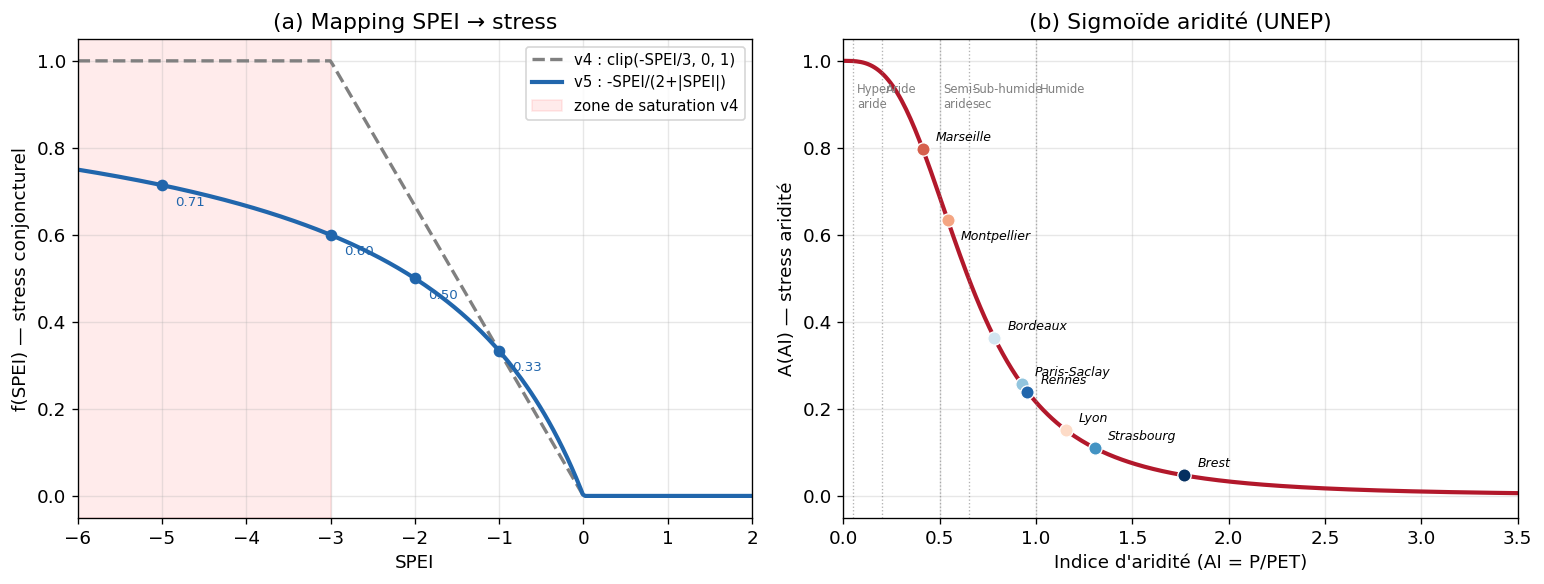

Fig 2 saved


In [6]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 11, 'figure.dpi': 120})

# ==================================================================
# Fig 2a — Mapping SPEI -> stress : clip (v4) vs asymptotique (v5)
# ==================================================================

spei_range = np.linspace(-6, 2, 300)

# v4 clip
f_clip = np.clip(-np.clip(spei_range, -3, 3) / 3.0, 0, 1)
# v5 asymptotique
f_asym = np.where(spei_range >= 0, 0.0, -spei_range / (2.0 + np.abs(spei_range)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(spei_range, f_clip, '--', color='gray', lw=2, label='v4 : clip(-SPEI/3, 0, 1)')
ax1.plot(spei_range, f_asym, '-', color='#2166ac', lw=2.5, label='v5 : -SPEI/(2+|SPEI|)')
ax1.axvspan(-6, -3, alpha=0.08, color='red', label='zone de saturation v4')
ax1.set_xlabel('SPEI')
ax1.set_ylabel('f(SPEI) — stress conjoncturel')
ax1.set_title('(a) Mapping SPEI → stress')
ax1.legend(loc='upper right', fontsize=9)
ax1.set_xlim(-6, 2)
ax1.set_ylim(-0.05, 1.05)
ax1.grid(True, alpha=0.3)
# Annotate key points
for spei_val, label in [(-1, '-1'), (-2, '-2'), (-3, '-3'), (-5, '-5')]:
    y_a = -spei_val / (2.0 + abs(spei_val))
    ax1.plot(spei_val, y_a, 'o', color='#2166ac', ms=6)
    ax1.annotate(f'{y_a:.2f}', (spei_val, y_a), textcoords='offset points',
                 xytext=(8, -12), fontsize=8, color='#2166ac')

# ==================================================================
# Fig 2b — Sigmoide aridite
# ==================================================================

ai_range = np.linspace(0.01, 3.5, 300)
A_stress = 1.0 / (1.0 + (ai_range / 0.65) ** 3)

ax2.plot(ai_range, A_stress, '-', color='#b2182b', lw=2.5)
ax2.set_xlabel('Indice d\'aridité (AI = P/PET)')
ax2.set_ylabel('A(AI) — stress aridité')
ax2.set_title('(b) Sigmoïde aridité (UNEP)')
ax2.set_xlim(0, 3.5)
ax2.set_ylim(-0.05, 1.05)
ax2.grid(True, alpha=0.3)

# UNEP thresholds
thresholds = [(0.05, 'Hyper-\naride'), (0.20, 'Aride'), (0.50, 'Semi-\naride'),
              (0.65, 'Sub-humide\nsec'), (1.0, 'Humide')]
for ai_th, lbl in thresholds:
    ax2.axvline(ai_th, color='gray', ls=':', lw=0.8, alpha=0.6)
    ax2.text(ai_th + 0.02, 0.95, lbl, fontsize=7, color='gray', va='top')

# Plot sites
site_colors = {'Marseille': '#d6604d', 'Montpellier': '#f4a582',
               'Lyon': '#fddbc7', 'Bordeaux': '#d1e5f0',
               'Paris-Saclay': '#92c5de', 'Strasbourg': '#4393c3',
               'Rennes': '#2166ac', 'Brest': '#053061'}
for _, row in df[df['year'] == 2022].iterrows():
    ai_val = row['AI']
    a_val = row['Aridity']
    ax2.plot(ai_val, a_val, 'o', color=site_colors.get(row['Site'], 'black'),
             ms=8, zorder=5, markeredgecolor='white', markeredgewidth=0.8)
    offset = (8, 5) if row['Site'] != 'Montpellier' else (8, -12)
    ax2.annotate(row['Site'], (ai_val, a_val), textcoords='offset points',
                 xytext=offset, fontsize=7.5, fontstyle='italic')

plt.tight_layout()
plt.savefig('fig2_transformations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 2 saved')


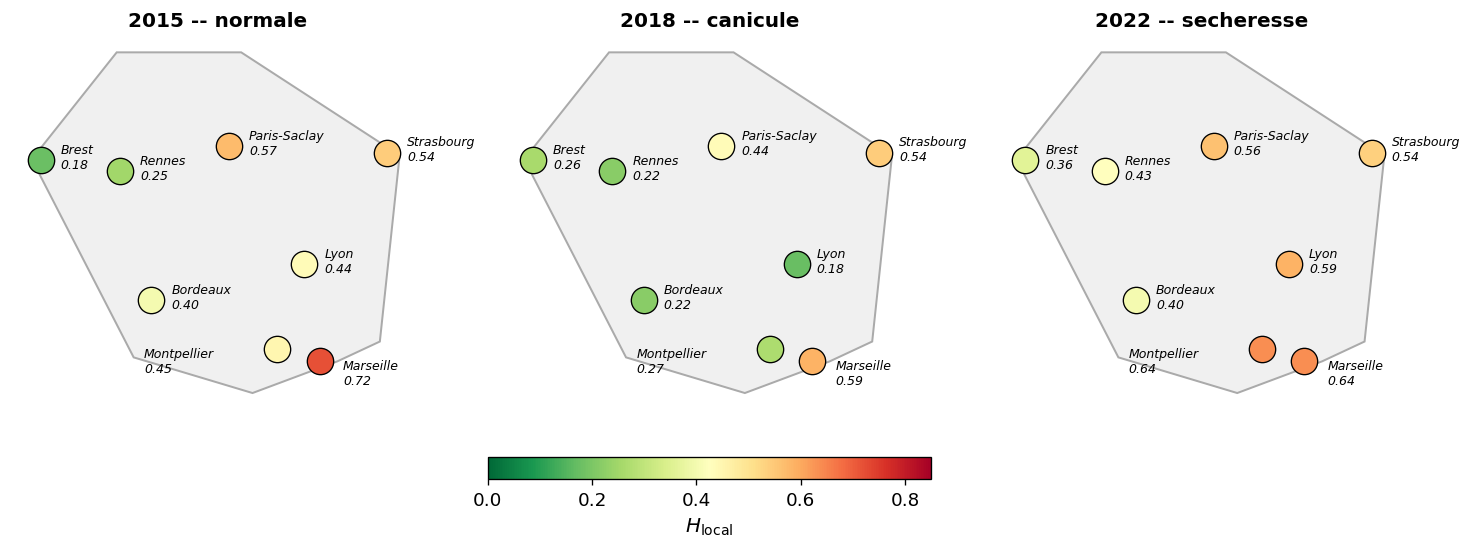

Fig 3 saved


In [7]:
# ==================================================================
# Fig 3 — Carte de France : H par site, 3 annees
# ==================================================================

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
cmap = plt.cm.RdYlGn_r  # vert=faible, rouge=eleve
norm = Normalize(vmin=0, vmax=0.85)

# Contour simplifie de la France
france_lon = [-1.8, 2.6, 8.2, 7.5, 6.0, 3.0, -1.2, -4.8, -1.8]
france_lat = [51.1, 51.1, 48.5, 43.8, 43.3, 42.5, 43.4, 48.4, 51.1]

for ax, year in zip(axes, [2015, 2018, 2022]):
    df_y = df[df['year'] == year]
    label_map = df_y['label'].iloc[0] if len(df_y) > 0 else ''
    ax.fill(france_lon, france_lat, color='#f0f0f0', edgecolor='#aaaaaa', lw=1.2)
    ax.set_xlim(-5.5, 9)
    ax.set_ylim(42, 51.5)
    ax.set_aspect(1.4)
    ax.set_title(f'{label_map}', fontweight='bold', fontsize=12)
    ax.axis('off')

    label_offsets = {
            'Marseille': (14, -14), 'Montpellier': (-80, -14),
            'Brest': (12, -5), 'Rennes': (12, -5),
            'Lyon': (12, -5), 'Bordeaux': (12, -5),
            'Paris-Saclay': (12, -5), 'Strasbourg': (12, -5),
        }
    for _, row in df_y.iterrows():
        lat, lon = SITES[row['Site']]
        h = row['H']
        ax.scatter(lon, lat, c=[h], cmap=cmap, norm=norm, s=250,
                   edgecolors='black', linewidths=0.8, zorder=5)
        off = label_offsets.get(row['Site'], (12, -5))
        ax.annotate(f"{row['Site']}\n{h:.2f}", (lon, lat),
                    textcoords='offset points', xytext=off,
                    fontsize=7.5, fontstyle='italic')

# Colorbar
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation='horizontal', fraction=0.04, pad=0.08)
cbar.set_label('$H_{\\mathrm{local}}$', fontsize=12)

plt.savefig('fig3_carte.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 3 saved')


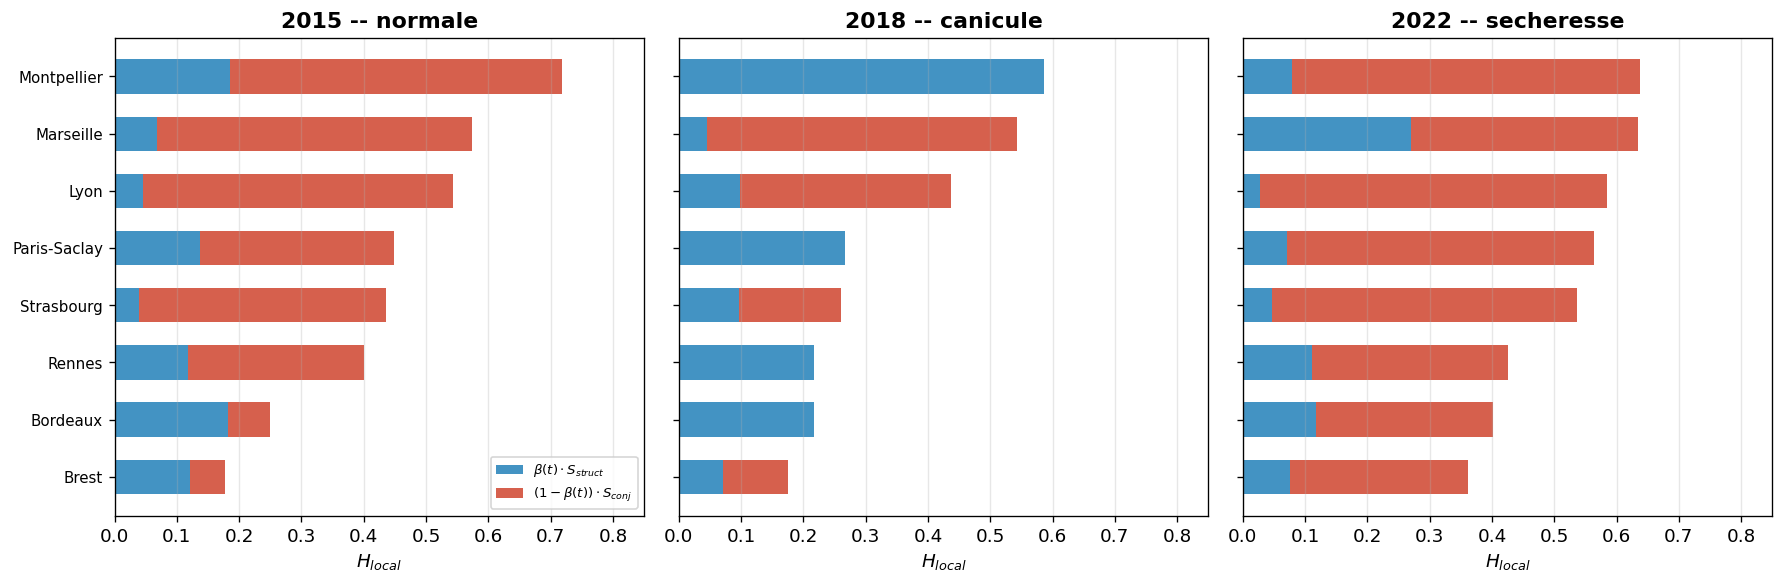

Fig 4 saved


In [8]:
# ==================================================================
# Fig 4 — Decomposition S_struct / S_conj empilee
# ==================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, year in zip(axes, [2015, 2018, 2022]):
    df_y = df[df['year'] == year].sort_values('H', ascending=True)
    sites = df_y['Site'].values
    y_pos = np.arange(len(sites))

    # Compute contributions with dynamic beta
    contrib_s = []
    contrib_c = []
    for _, row in df_y.iterrows():
        s_conj = row['S_conj']
        s_struct = row['S_struct']
        beta_t = 0.70 * (1.0 - s_conj)
        cs = beta_t * s_struct
        cc = (1.0 - beta_t) * s_conj
        contrib_s.append(cs)
        contrib_c.append(cc)

    ax.barh(y_pos, contrib_s, height=0.6, color='#4393c3', label='$\\beta(t) \\cdot S_{struct}$')
    ax.barh(y_pos, contrib_c, height=0.6, left=contrib_s, color='#d6604d', label='$(1-\\beta(t)) \\cdot S_{conj}$')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sites, fontsize=9)
    ax.set_xlim(0, 0.85)
    ax.set_xlabel('$H_{local}$')
    label_y = df_y['label'].iloc[0] if len(df_y) > 0 else ''
    ax.set_title(f'{label_y}', fontweight='bold')
    ax.grid(True, axis='x', alpha=0.3)
    if year == 2015:
        ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('fig4_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 4 saved')


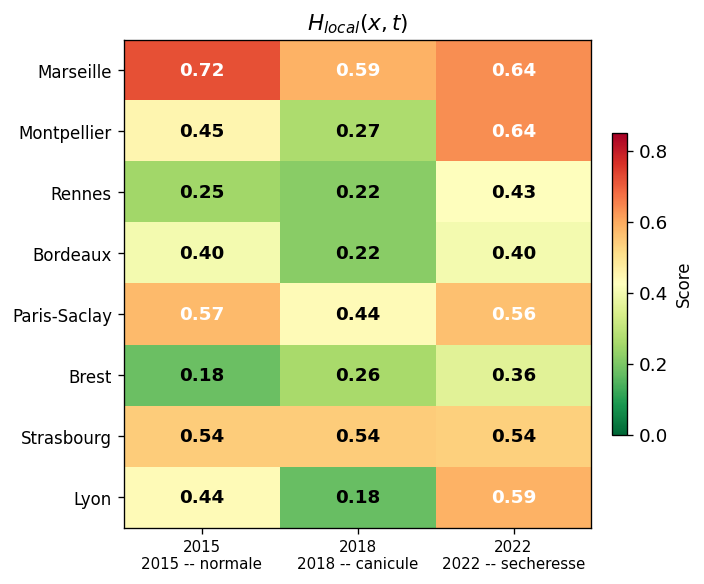

Fig 5 saved


In [9]:
# ==================================================================
# Fig 5 — Heatmap H(site x annee)
# ==================================================================

pivot = df.pivot_table(index='Site', columns='year', values='H')
# Sort by S_struct descending
struct_order = df.groupby('Site')['S_struct'].mean().sort_values(ascending=False)
pivot = pivot.loc[struct_order.index]

fig, ax = plt.subplots(figsize=(6, 5))
cmap = plt.cm.RdYlGn_r
im = ax.imshow(pivot.values, cmap=cmap, aspect='auto', vmin=0, vmax=0.85)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f'{y}\n{df[df["year"]==y]["label"].iloc[0]}' for y in pivot.columns], fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=10)

# Annotate values
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        color = 'white' if val > 0.55 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=11,
                fontweight='bold', color=color)

ax.set_title('$H_{local}(x, t)$', fontsize=13, fontweight='bold')
cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label('Score', fontsize=10)

plt.tight_layout()
plt.savefig('fig5_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 5 saved')


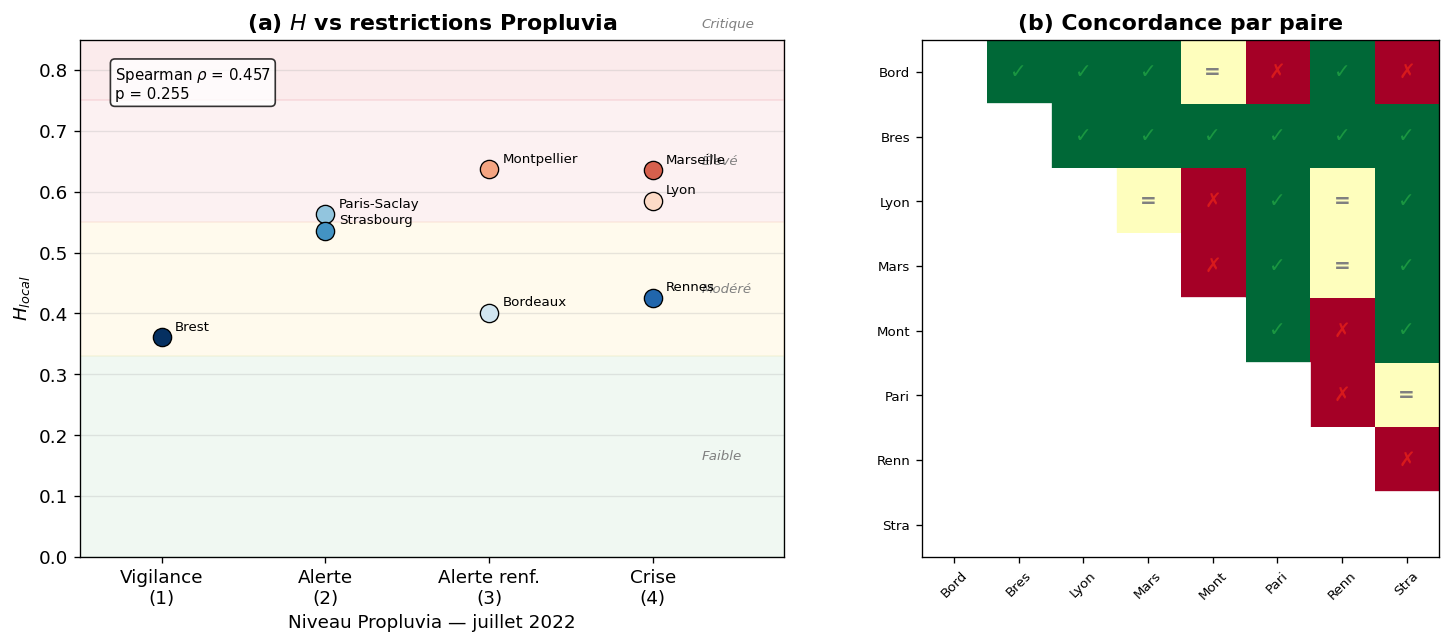

Fig 6 saved


In [10]:
# ==================================================================
# Fig 6 — Scatter H vs Propluvia + Fig 7 concordance
# ==================================================================

PROPLUVIA_JUL2022 = {
    'Paris-Saclay': 2, 'Lyon': 4, 'Marseille': 4, 'Strasbourg': 2,
    'Brest': 1, 'Rennes': 4, 'Bordeaux': 3, 'Montpellier': 3,
}
PROPLUVIA_LABELS = {1: 'Vigilance', 2: 'Alerte', 3: 'Alerte renf.', 4: 'Crise'}

df_2022 = df[df['year'] == 2022].copy()
df_2022['Propluvia'] = df_2022['Site'].map(PROPLUVIA_JUL2022)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

# --- 6a: Scatter ---
# Background categories
cat_colors = {'Faible': '#d4edda', 'Modéré': '#fff3cd', 'Élevé': '#f8d7da', 'Critique': '#f5c6cb'}
cat_bounds = [(0, 0.33, 'Faible'), (0.33, 0.55, 'Modéré'), (0.55, 0.75, 'Élevé'), (0.75, 1.0, 'Critique')]
for lo, hi, label in cat_bounds:
    ax1.axhspan(lo, hi, alpha=0.35, color=cat_colors[label])
    ax1.text(4.3, (lo+hi)/2, label, fontsize=8, va='center', ha='left',
             fontstyle='italic', color='gray')

for _, row in df_2022.iterrows():
    col = site_colors.get(row['Site'], 'black')
    ax1.scatter(row['Propluvia'], row['H'], c=col, s=120, edgecolors='black',
                linewidths=0.8, zorder=5)
    ax1.annotate(row['Site'], (row['Propluvia'], row['H']),
                 textcoords='offset points', xytext=(8, 4), fontsize=8)

ax1.set_xticks([1, 2, 3, 4])
ax1.set_xticklabels(['Vigilance\n(1)', 'Alerte\n(2)', 'Alerte renf.\n(3)', 'Crise\n(4)'])
ax1.set_xlabel('Niveau Propluvia — juillet 2022')
ax1.set_ylabel('$H_{local}$')
ax1.set_title('(a) $H$ vs restrictions Propluvia', fontweight='bold')
ax1.set_xlim(0.5, 4.8)
ax1.set_ylim(0, 0.85)
ax1.grid(True, axis='y', alpha=0.3)

# Spearman annotation
from scipy.stats import spearmanr
rho, pval = spearmanr(df_2022['Propluvia'], df_2022['H'])
ax1.text(0.05, 0.95, f'Spearman $\\rho$ = {rho:.3f}\np = {pval:.3f}',
         transform=ax1.transAxes, fontsize=9, va='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# --- 6b: Concordance matrix ---
sites_sorted = sorted(SITES.keys())
n = len(sites_sorted)
concordance = np.full((n, n), np.nan)

h_dict = dict(zip(df_2022['Site'], df_2022['H']))
p_dict = PROPLUVIA_JUL2022

for i in range(n):
    for j in range(i+1, n):
        si, sj = sites_sorted[i], sites_sorted[j]
        hi, hj = h_dict[si], h_dict[sj]
        pi, pj = p_dict[si], p_dict[sj]
        if pi == pj:
            concordance[i, j] = 0.5  # tie
        elif (hi - hj) * (pi - pj) > 0:
            concordance[i, j] = 1.0  # concordant
        else:
            concordance[i, j] = 0.0  # discordant

cmap_conc = plt.cm.RdYlGn
im = ax2.imshow(concordance, cmap=cmap_conc, vmin=0, vmax=1)
ax2.set_xticks(range(n))
ax2.set_xticklabels([s[:4] for s in sites_sorted], rotation=45, fontsize=8)
ax2.set_yticks(range(n))
ax2.set_yticklabels([s[:4] for s in sites_sorted], fontsize=8)
ax2.set_title('(b) Concordance par paire', fontweight='bold')

for i in range(n):
    for j in range(i+1, n):
        val = concordance[i, j]
        if not np.isnan(val):
            sym = '\u2713' if val == 1 else ('=' if val == 0.5 else '\u2717')
            color = '#1a9641' if val == 1 else ('#d7191c' if val == 0 else 'gray')
            ax2.text(j, i, sym, ha='center', va='center', fontsize=12,
                     fontweight='bold', color=color)
    # Hide lower triangle
    for j in range(0, i+1):
        ax2.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=True, color='white'))

plt.tight_layout()
plt.savefig('fig6_propluvia.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 6 saved')


df_2022 shape: (8, 13)
Columns: ['Site', 'year', 'label', 'S_struct', 'S_conj', 'H', 'BWS', 'Aridity', 'GWS', 'AI', 'SPEI12', 'SPEI3', '%_struct']
H_ref: {'Paris-Saclay': 0.5631716166350897, 'Lyon': 0.5851953727963021, 'Marseille': 0.6350863632077108, 'Strasbourg': 0.536262945528545, 'Brest': 0.361572712831947, 'Rennes': 0.4258785796735065, 'Bordeaux': 0.4014229898434195, 'Montpellier': 0.6370491120934868}
ref_mean: 0.5182

Tornado data:
          $\beta_0$ [0.50, 0.90]  lo=-0.0181  hi=+0.0181
               $\alpha$ BWS dom.  lo=-0.0053  hi=+0.0000
              $\alpha$ Arid dom.  lo=+0.0000  hi=+0.0030
         BWS$_{max}$ [0.30, 1.0]  lo=-0.0175  hi=+0.0308
        GWS$_{max}$ [0.10, 0.50]  lo=-0.0152  hi=+0.0029
               $k_{arid}$ [1, 8]  lo=-0.0082  hi=+0.0116
            $c$ asympt. [0.5, 5]  lo=-0.1570  hi=+0.2589
          $\tau$ softmax [0, 50]  lo=-0.0277  hi=+0.0242
           $\beta$ dynamique OFF  lo=-0.1115  hi=+0.0000


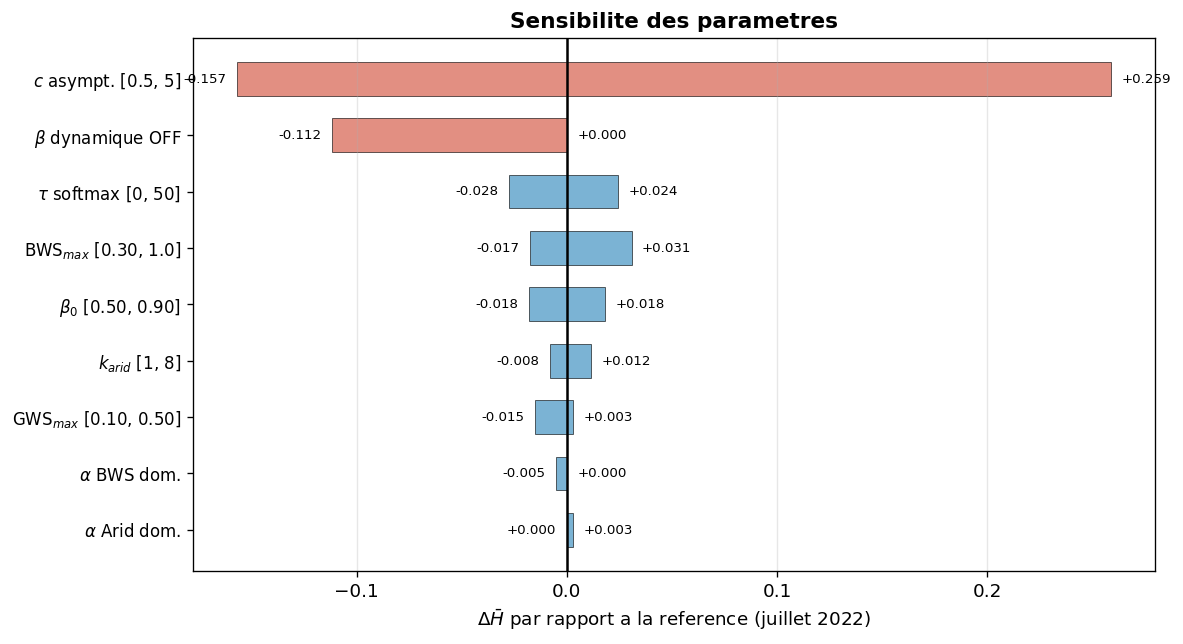

Fig 8 saved


In [11]:
# ==================================================================
# Fig 8 — Tornado plot : sensibilite des parametres
# ==================================================================

def recompute_H(df_year, bws_max=0.60, gws_max=0.15, k_arid=3.0,
                alpha=None, beta_0=0.70, c_asym=2.0, tau=5.0, dynamic_beta=True):
    """Recompute H from df rows with parameter overrides."""
    if alpha is None:
        alpha = {'bws': 0.50, 'aridity': 0.36, 'gws': 0.14}
    results = {}
    for _, row in df_year.iterrows():
        # Back to raw values then rescale
        bws_raw = row['BWS'] * 0.60  # BWS in df = raw/0.60
        gws_raw = row['GWS'] * 0.15  # GWS in df = raw/0.15
        b = float(np.clip(bws_raw / bws_max, 0, 1))
        g = float(np.clip(gws_raw / gws_max, 0, 1))
        ai = row['AI']
        a = 1.0 / (1.0 + (ai / 0.65) ** k_arid) if ai > 0 else 1.0

        comps = {'bws': b, 'aridity': a, 'gws': g}
        num = sum(alpha[k] * v for k, v in comps.items() if not np.isnan(v))
        den = sum(alpha[k] for k, v in comps.items() if not np.isnan(v))
        s_struct = num / den if den > 0 else np.nan

        spei12 = row['SPEI12']
        spei3 = row['SPEI3']
        d12 = 0.0 if (np.isnan(spei12) or spei12 >= 0) else -spei12 / (c_asym + abs(spei12))
        d3  = 0.0 if (np.isnan(spei3) or spei3 >= 0) else -spei3 / (c_asym + abs(spei3))

        if tau > 0:
            e12 = np.exp(np.clip(tau * d12, -500, 500))
            e3  = np.exp(np.clip(tau * d3, -500, 500))
            s_conj = (d12 * e12 + d3 * e3) / (e12 + e3)
        else:
            s_conj = 0.5 * d12 + 0.5 * d3

        beta_t = beta_0 * (1.0 - s_conj) if dynamic_beta else beta_0
        if np.isnan(s_struct):
            H = s_conj
        elif np.isnan(s_conj):
            H = s_struct
        else:
            H = beta_t * s_struct + (1 - beta_t) * s_conj
        results[row['Site']] = float(np.clip(H, 0, 1))
    return results

df_2022 = df[df['year'] == 2022].copy()
print(f"df_2022 shape: {df_2022.shape}")
print(f"Columns: {list(df_2022.columns)}")

# Reference
H_ref = recompute_H(df_2022)
ref_mean = np.mean(list(H_ref.values()))
print(f"H_ref: {H_ref}")
print(f"ref_mean: {ref_mean:.4f}")

# Parameter perturbations
tornado_data = []
tests = [
    ('$\\beta_0$ [0.50, 0.90]', [{'beta_0': 0.50}, {'beta_0': 0.90}]),
    ('$\\alpha$ BWS dom.', [{'alpha': {'bws': 0.70, 'aridity': 0.20, 'gws': 0.10}}]),
    ('$\\alpha$ Arid dom.', [{'alpha': {'bws': 0.25, 'aridity': 0.60, 'gws': 0.15}}]),
    ('BWS$_{max}$ [0.30, 1.0]', [{'bws_max': 0.30}, {'bws_max': 1.00}]),
    ('GWS$_{max}$ [0.10, 0.50]', [{'gws_max': 0.10}, {'gws_max': 0.50}]),
    ('$k_{arid}$ [1, 8]', [{'k_arid': 1.0}, {'k_arid': 8.0}]),
    ('$c$ asympt. [0.5, 5]', [{'c_asym': 0.5}, {'c_asym': 5.0}]),
    ('$\\tau$ softmax [0, 50]', [{'tau': 0.0}, {'tau': 50.0}]),
    ('$\\beta$ dynamique OFF', [{'dynamic_beta': False}]),
]

for label, variants in tests:
    h_means = [ref_mean]
    for kw in variants:
        H = recompute_H(df_2022, **kw)
        h_means.append(np.mean(list(H.values())))
    lo = min(h_means) - ref_mean
    hi = max(h_means) - ref_mean
    tornado_data.append((label, lo, hi))

# Debug
print("\nTornado data:")
for label, lo, hi in tornado_data:
    print(f"  {label:>30s}  lo={lo:+.4f}  hi={hi:+.4f}")

# Sort by total range
tornado_data.sort(key=lambda x: abs(x[2] - x[1]))

fig, ax = plt.subplots(figsize=(10, 5.5))
y_pos = np.arange(len(tornado_data))

for i, (lbl, lo, hi) in enumerate(tornado_data):
    width = hi - lo
    color = '#d6604d' if width > 0.06 else '#4393c3'
    ax.barh(i, hi, height=0.6, color=color, alpha=0.7,
            edgecolor='black', linewidth=0.5)
    ax.barh(i, lo, height=0.6, color=color, alpha=0.7,
            edgecolor='black', linewidth=0.5)
    # Value labels
    ax.text(min(lo, hi) - 0.005, i, f'{min(lo,hi):+.3f}', ha='right', va='center', fontsize=8)
    ax.text(max(lo, hi) + 0.005, i, f'{max(lo,hi):+.3f}', ha='left', va='center', fontsize=8)

ax.set_yticks(y_pos)
ax.set_yticklabels([t[0] for t in tornado_data], fontsize=10)
ax.axvline(0, color='black', lw=1.5)
ax.set_xlabel('$\\Delta \\bar{H}$ par rapport a la reference (juillet 2022)', fontsize=11)
ax.set_title('Sensibilite des parametres', fontweight='bold', fontsize=13)
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('fig8_tornado.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 8 saved')


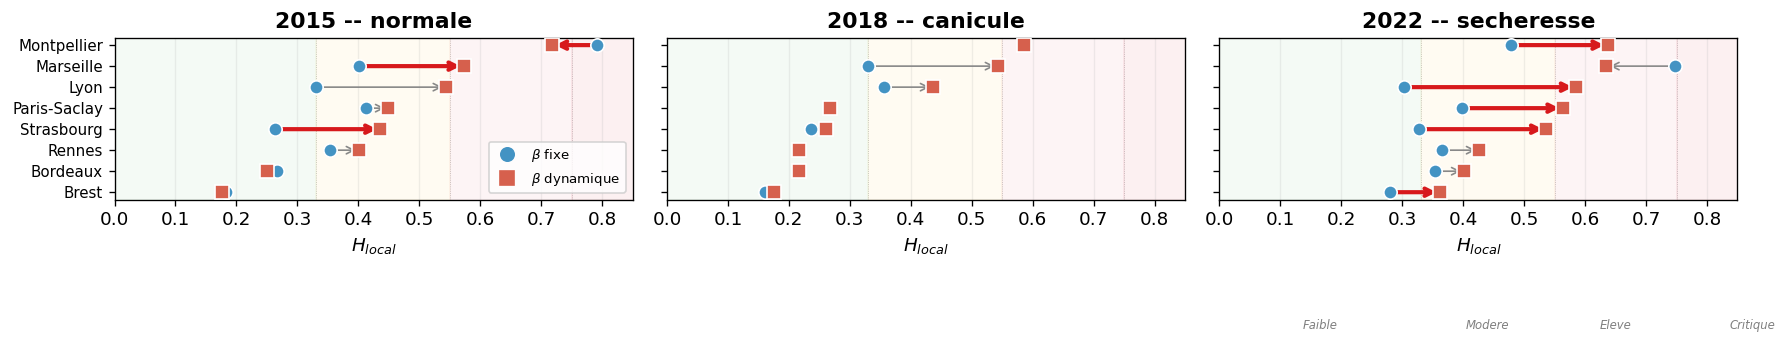

Fig 10 saved


In [12]:
# ==================================================================
# Fig 10 — Effet beta dynamique : dot plot avec seuils
# ==================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

cat_bounds = [(0, 0.33, 'Faible', '#d4edda'), (0.33, 0.55, 'Modere', '#fff3cd'),
              (0.55, 0.75, 'Eleve', '#f8d7da'), (0.75, 1.0, 'Critique', '#f5c6cb')]

for ax, year in zip(axes, [2015, 2018, 2022]):
    H_dyn = recompute_H(df[df["year"]==year], dynamic_beta=True)
    H_fix = recompute_H(df[df["year"]==year], dynamic_beta=False)

    # Background categories
    for lo, hi, lbl, col in cat_bounds:
        ax.axvspan(lo, hi, alpha=0.25, color=col)
        ax.axvline(lo, color='gray', ls=':', lw=0.5, alpha=0.5)

    sites_sorted = sorted(SITES.keys(), key=lambda s: H_dyn[s])
    y_pos = np.arange(len(sites_sorted))

    for i, site in enumerate(sites_sorted):
        hf = H_fix[site]
        hd = H_dyn[site]
        # Check if crosses category boundary
        def cat(h):
            for lo, hi, lbl, _ in cat_bounds:
                if lo <= h < hi: return lbl
            return 'Critique'
        crosses = cat(hf) != cat(hd)
        arrow_color = '#d7191c' if crosses else '#888888'
        lw = 2.5 if crosses else 1.0
        ax.annotate('', xy=(hd, i), xytext=(hf, i),
                    arrowprops=dict(arrowstyle='->', color=arrow_color, lw=lw))
        ax.plot(hf, i, 'o', color='#4393c3', ms=8, zorder=5, markeredgecolor='white')
        ax.plot(hd, i, 's', color='#d6604d', ms=8, zorder=5, markeredgecolor='white')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(sites_sorted, fontsize=9)
    ax.set_xlim(0, 0.85)
    label_y = df[df['year']==year]['label'].iloc[0]
    ax.set_title(f'{label_y}', fontweight='bold')
    ax.set_xlabel('$H_{local}$')
    ax.grid(True, axis='x', alpha=0.2)

    if year == 2015:
        ax.plot([], [], 'o', color='#4393c3', ms=8, label='$\\beta$ fixe')
        ax.plot([], [], 's', color='#d6604d', ms=8, label='$\\beta$ dynamique')
        ax.legend(loc='lower right', fontsize=8)

# Category labels on top of last panel only, below title
for lo, hi, lbl, _ in cat_bounds:
    axes[-1].text((lo+hi)/2, -0.8, lbl, fontsize=7, ha='center',
                  color='gray', fontstyle='italic', transform=axes[-1].get_xaxis_transform())

plt.tight_layout()
plt.savefig('fig10_beta_dynamique.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 10 saved')


---
## 6. Limitations

Ce score est un **prototype opérationnel**, pas un modèle hydrologique.

### Ce que $H_{\text{local}}$ est

- Un **score décisionnel territorial brut** : il agrège des indicateurs publics pour comparer des sites.
- Un signal **interprétable** : chaque composante a un sens physique documenté.
- Un point de départ pour une analyse plus fine (couche besoin DC, calibration).

### Ce que $H_{\text{local}}$ n'est pas

| Limitation | Détail |
|---|---|
| **Pas un modèle hydrologique** | Pas de bilan hydrique, pas de modélisation pluie-débit, pas de nappe phréatique dynamique. |
| **Pas calibré** | Tous les poids ($\alpha$, $\beta$) sont fixés à dire d'expert. Pas d'AHP, pas de régression, pas de validation croisée. |
| **Pas DC-aware** | Ne modélise pas le besoin du data center (MW vers m3, type de refroidissement, profil saisonnier, contraintes de prélèvement). |
| **Score décisionnel, pas neutre** | Le $\max(\text{SPEI-3}, \text{SPEI-12})$ est conservateur par design. Le cap à $[-3,+3]$ perd de l'information extrême. |
| **Contributions = design, pas physique** | Les % struct/conj dépendent de la normalisation et des poids, pas d'une vérité physique. |
| **8 sites, 3 dates** | Validation minimale. Pas de couverture spatiale exhaustive ni de validation temporelle complète. |
| **ERA5 = 28 km** | Résolution insuffisante pour les effets locaux (vallées, microclimats urbains). |
| **Aridity = baseline figée** | L'AI est calculé sur 1981-2010. Sous changement climatique, cette référence vieillit. |

### Prochaines étapes

1. **Couche besoin DC** : transformer le score territorial en score de compatibilité site x data center.
2. **Calibration** : ajuster les poids sur des données de terrain (débits, piézométrie, retours d'exploitants).
3. **Résolution spatiale** : descendre à 5 km avec rasters prétraités.
4. **Temporalité** : intégrer des scénarios climatiques (CMIP6 / DRIAS-2020) pour projection 2030-2050.

### Choix du mapping SPEI

Le mapping asymptotique $f(\text{SPEI}) = -\text{SPEI}/(2+|\text{SPEI}|)$
remplace le clip linéaire $f = \text{clip}(-\text{SPEI}/3, 0, 1)$ qui **saturait à 1.0**
en crise généralisée (été 2022), détruisant toute variance entre sites.
La sigmoïde préserve de la discrimination même en extrême.

### Beta dynamique

$\beta(t) = \beta_0 \cdot (1 - S_{\text{conj}})$ : en temps calme ($S_{\text{conj}} \approx 0$),
la structure domine ; en crise ($S_{\text{conj}} \to 1$), le conjoncturel prend le relais.
Cela évite que le classement final soit figé par $S_{\text{struct}}$ quand la crise sature.